# ✍️ Handwritten Digit Recognition using Convolutional Neural Networks (CNN)

## 📌 Project Overview

Convolutional Neural Networks (CNNs) are specialized Deep Learning models designed for image processing and computer vision tasks. Unlike traditional Artificial Neural Networks (ANNs), CNNs automatically extract important features such as edges, textures, and shapes from images.

In this project, a CNN model is developed to recognize handwritten digits (0–9) using a custom MNIST image dataset. The project demonstrates the complete Deep Learning workflow, including data loading, preprocessing, CNN model development, training, evaluation, prediction, and model saving using TensorFlow and Keras.

---

## 🎯 Objective

- Understand the architecture of Convolutional Neural Networks.
- Learn how image data is preprocessed.
- Build and train a CNN model.
- Classify handwritten digits accurately.
- Evaluate the model using a confusion matrix.

# 📚 Import Required Libraries

The following libraries are imported for image processing, data handling, visualization, model building, and evaluation.

In [3]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
#Load configuration from JSON file
def load_config(file_path):
    with open(file_path, 'r') as file:
        config = json.load(file)
        return config
config = load_config(r"assets\Data.json")
print(config)   

{'dataset_dir': 'Data/mnist_images', 'dataset_csv_file': 'Data/mnist_images/0labels.csv', 'train_dir': 'Data/mnist_images/x_train', 'train_csv_file': 'Data/mnist_images/x_train/0labels.csv', 'test_dir': 'Data/mnist_images/x_test', 'test_csv_file': 'Data/mnist_images/x_test/0labels.csv', 'model_path': 'model/MNISTmodel.h5'}


In [5]:
#Load dataset and labels
ds_dir = config["dataset_dir"]
labels_df = pd.read_csv(config["dataset_csv_file"])
print(labels_df.head())

  image_filename  label
0    image_1.jpg      5
1    image_2.jpg      0
2    image_3.jpg      4
3    image_4.jpg      1
4    image_5.jpg      9


In [6]:
#View dataset information
labels_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   image_filename  1000 non-null   str  
 1   label           1000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 28.3 KB


In [7]:
#Prepare the data for training and testing
x = labels_df['image_filename'].astype(str).to_numpy(dtype=str)
y = labels_df['label'].to_numpy()

In [8]:
#Prepocessing function to load images and convert them to numpy arrays
def load_images(filenames, folder_path, target_size=(28, 28)):
    images = []
    for filename in filenames:
        img_path = os.path.join(folder_path, filename)
        img = load_img(img_path, target_size=target_size)
        img = img_to_array(img) / 255.0
        images.append(img)
    return np.array(images)

In [9]:
#Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
#Load images for training and testing
x_train = load_images(x_train, ds_dir)
x_test = load_images(x_test, ds_dir)

In [11]:
#Convert labels to categorical format by One-Hot Encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [12]:
#Define the CNN model architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\PCM\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
#Printing Models Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,898 (366.79 KB)

 Trainable params: 93,898 (366.79 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#Compiling the model
model.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])

In [15]:
#Training The Model
x_train_new, x_val, y_train_new, y_val = train_test_split(x_train, y_train, random_state=42, test_size=0.2)
history = model.fit(x_train_new,y_train_new,epochs=15,batch_size=64, validation_data=(x_val,y_val))

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.3344 - loss: 2.1416 - val_accuracy: 0.5437 - val_loss: 1.7395
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6516 - loss: 1.2513 - val_accuracy: 0.7937 - val_loss: 0.8027
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7922 - loss: 0.6248 - val_accuracy: 0.8375 - val_loss: 0.5040
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8594 - loss: 0.4386 - val_accuracy: 0.9000 - val_loss: 0.4464
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8922 - loss: 0.3305 - val_accuracy: 0.9312 - val_loss: 0.3561
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9156 - loss: 0.2448 - val_accuracy: 0.9375 - val_loss: 0.3091
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9516 - loss: 0.1864 - val_accuracy: 0.9438 - val_loss: 0.2842
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9609 - loss: 0.1509 - val_accuracy: 0.9438 - 

In [16]:
#Svaing the Trained Model
model.save(config["model_path"])

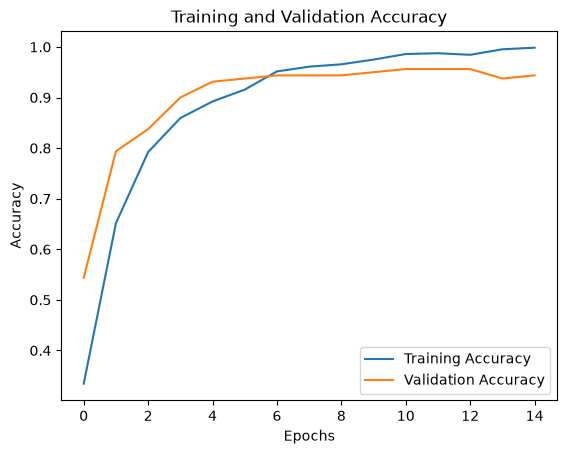

In [17]:
#Ploting the Graphs to Visualize the results
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

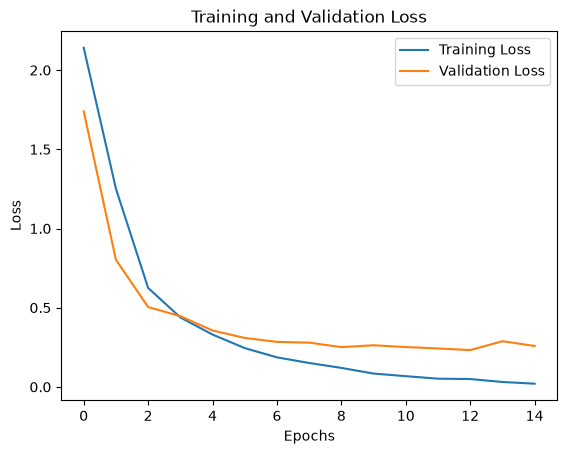

In [18]:
#Visualizing Loss
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
#Performing the Predictions on test Data
pred = model.predict(x_test)
text_pred = np.argmax(pred , axis=1)
text_labels = np.argmax(y_test, axis=1)
cm = confusion_matrix(text_labels,text_pred)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


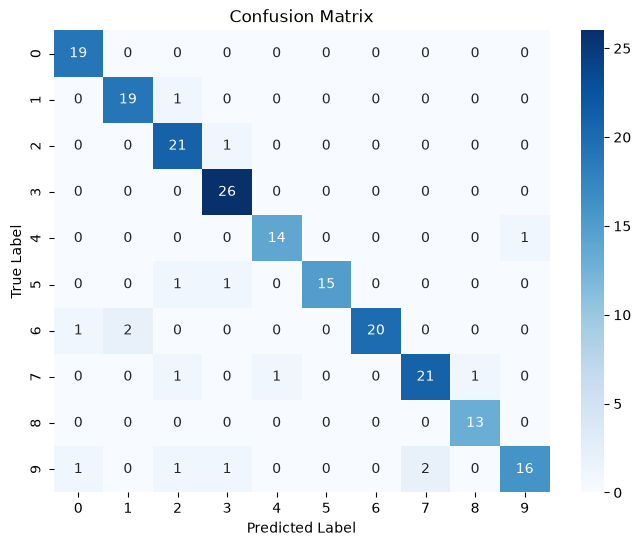

In [20]:
#Plotting Confusion Matrix for the Predicted Model
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

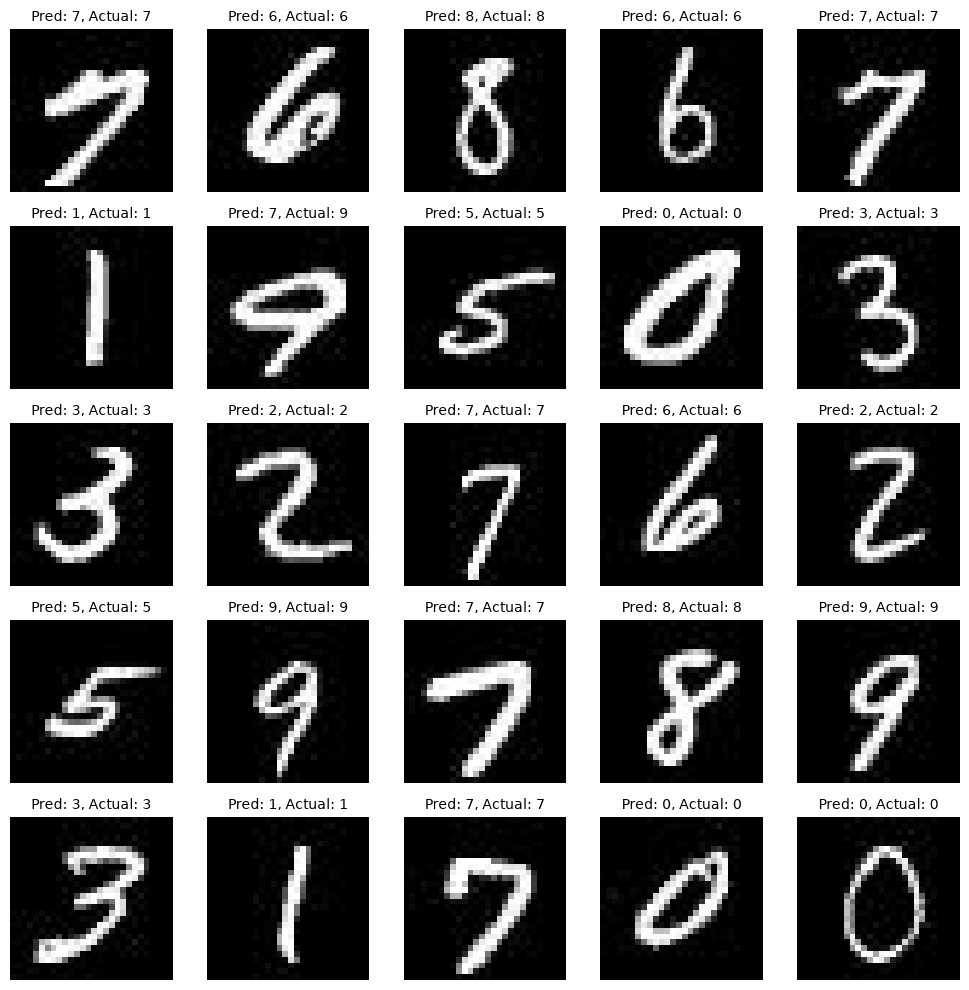

In [21]:
#Another Visualization Plots
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()

for i in range(25):
    ax = axes[i]
    
    ax.imshow(x_test[i].reshape(28, 28, 3))  
    ax.axis('off')
    
    predicted_label = np.argmax(pred[i])
    actual_label = np.argmax(y_test[i])
    
    ax.set_title(f"Pred: {predicted_label}, Actual: {actual_label}", fontsize=10)

plt.tight_layout() 
plt.show()

# ✅ Conclusion

In this project, a Convolutional Neural Network (CNN) was successfully developed to recognize handwritten digits using the MNIST image dataset. The dataset was preprocessed by loading images, normalizing pixel values, and splitting the data into training and testing sets.

The CNN model learned meaningful image features through convolution and pooling operations, resulting in high classification accuracy. The model was evaluated using a confusion matrix and successfully predicted handwritten digits on unseen test images.

This project demonstrates the effectiveness of CNNs for image classification tasks and provides a strong foundation for more advanced computer vision applications such as object detection, facial recognition, and medical image analysis.

# 📚 Key Learnings

- Understood the fundamentals of Convolutional Neural Networks (CNNs).
- Learned the role of convolution, activation, pooling, flatten, and dense layers.
- Worked with a custom image dataset instead of built-in datasets.
- Loaded image data using TensorFlow's image preprocessing utilities.
- Normalized image pixel values for better model performance.
- Split image data into training and testing sets.
- Built and trained a CNN using TensorFlow and Keras.
- Evaluated model performance using a confusion matrix.
- Saved the trained model for future predictions.
- Gained practical experience in image classification using Deep Learning.